In [1]:
import os
os.environ.setdefault("OPENCV_IO_ENABLE_OPENEXR", "1")  # must be set before cv2 loads

import cv2
import numpy as np
import plotly.graph_objects as go
import sys
import matplotlib.pyplot as plt
import rtm_det.rtmpose as rtm

In [2]:
DATA = "SynthHuman_0025"
MODEL = "rtm_det/rtmpose.onnx"
FAR = 65504.0

# Halpe26: COCO 17 + head(17) neck(18) pelvis(19) + toes/heels(20-25)
EDGES = [(17, 18), (18, 19), (18, 5), (18, 6), (5, 7), (7, 9), (6, 8), (8, 10),
         (19, 11), (19, 12), (11, 13), (13, 15), (12, 14), (14, 16),
         (15, 20), (15, 24), (16, 21), (16, 25), (0, 18)]

def load(sample):
    """Return rgb (BGR), depth (cm, 65504 = background) and the 3x3 intrinsics."""
    rgb = cv2.imread(f"{DATA}/rgb_{sample}.png")
    depth = cv2.imread(f"{DATA}/depth_{sample}.exr", cv2.IMREAD_UNCHANGED)
    K = np.loadtxt(f"{DATA}/cam_{sample}.txt")
    return rgb, depth, K

def person_boxes(depth, min_area=2000):
    """One box per connected component of the foreground: the dataset's own segmentation."""
    n, _, stats, _ = cv2.connectedComponentsWithStats((depth < FAR).astype(np.uint8), 8)
    return [(x, y, x + w, y + h) for x, y, w, h, a in stats[1:] if a >= min_area]

def keypoints(sess, rgb, box):
    """Run RTMPose on one box. Cropping lets rtmpose.preprocess use the crop as the box."""
    x0, y0, x1, y1 = box
    h, w = sess.get_inputs()[0].shape[2:]
    img, center, scale = rtm.preprocess(rgb[y0:y1, x0:x1], (w, h))
    kp, scores = rtm.postprocess(rtm.inference(sess, img), (w, h), center, scale)
    return kp[0] + [x0, y0], scores[0]

def to_3d(kp, depth, K):
    """Lift each keypoint with the depth around it: Z from the map, X/Y from the pinhole model."""
    fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
    points = []
    for u, v in kp.astype(int):
        for r in (4, 12):  # keypoints can land a few px off the silhouette
            patch = depth[max(v - r, 0):v + r, max(u - r, 0):u + r]
            patch = patch[patch < FAR]
            if patch.size:
                break
        # 25th percentile, not the mean: if the window straddles two body parts
        # (wrist over torso) the keypoint belongs to the nearer surface.
        Z = np.percentile(patch, 25) if patch.size else np.nan
        points.append([(u - cx) * Z / fx, (v - cy) * Z / fy, Z])
    return np.array(points)

def plot(sample, people):
    """Interactive plot. Camera y points down, so plot (X, Z, -Y) to stand people up."""
    fig = go.Figure()
    for i, P in enumerate(people):
        ok = np.isfinite(P).all(1)
        color = ["#e6194b", "#4363d8", "#3cb44b"][i % 3]
        x, y, z = P[:, 0], P[:, 2], -P[:, 1]
        bones = [[(x[a], x[b], None), (y[a], y[b], None), (z[a], z[b], None)]
                 for a, b in EDGES if ok[a] and ok[b]]
        fig.add_scatter3d(x=np.concatenate([b[0] for b in bones]),
                          y=np.concatenate([b[1] for b in bones]),
                          z=np.concatenate([b[2] for b in bones]),
                          mode="lines", line=dict(color=color, width=5), name=f"person {i}")
        fig.add_scatter3d(x=x[ok], y=y[ok], z=z[ok], mode="markers",
                          marker=dict(size=4, color=color), name=f"person {i} joints",
                          text=[str(j) for j in np.nonzero(ok)[0]])
    fig.update_layout(title=f"{sample}: 3D keypoints from depth (cm)",
                      scene=dict(xaxis_title="X (cm)", yaxis_title="Z depth (cm)",
                                 zaxis_title="Y up (cm)", aspectmode="data"),
                      width=900, height=700) # Added explicit size for notebook layout
    return fig

person at 239-302 cm, thigh 20 cm, shin 34 cm
1 person(s) detected.


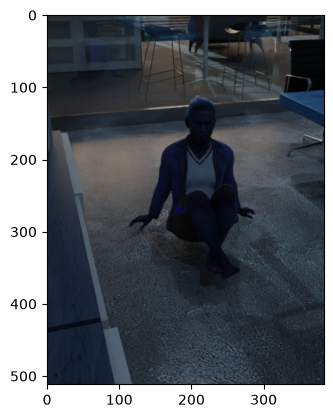

In [3]:
# Change this ID to test different samples (e.g., "0125000", "0126440")
sample = "0125037" 

rgb, depth, K = load(sample)
sess = rtm.build_session(MODEL)

people = []
for box in person_boxes(depth):
    kp, scores = keypoints(sess, rgb, box)
    if scores.mean() < 0.35:  # rejects rendered props, not people (people score 0.5-1.0)
        continue
    P = to_3d(kp, depth, K)
    people.append(P)
    print(f"person at {np.nanmin(P[:, 2]):.0f}-{np.nanmax(P[:, 2]):.0f} cm, "
          f"thigh {np.linalg.norm(P[11] - P[13]):.0f} cm, shin {np.linalg.norm(P[13] - P[15]):.0f} cm")

print(f"{len(people)} person(s) detected.")

# Generate and display the interactive 3D plot inline
fig = plot(sample, people)
fig.show()


plt.imshow(rgb)
plt.show()

In [4]:
def plot_depth_interactive(sample, depth):
    """Plots the raw depth map interactively, clamping the background to black."""
    fig = go.Figure(data=go.Heatmap(
        z=depth, 
        zmin=0,          # Changed from cmin to zmin
        zmax=350,         # Changed from cmax to zmax
        colorscale='Viridis',
        colorbar=dict(title="Depth (cm)")
    ))
    
    fig.update_layout(
        title=f"{sample}: Raw Depth Map (cm)",
        xaxis_title="u (pixels)",
        yaxis_title="v (pixels)",
        yaxis=dict(autorange="reversed"), # Camera y points down, so flip the y-axis
        width=700,
        height=900
    )
    return fig


# 1. Plot the interactive 2D depth map
print("\n--- Depth Map ---")
fig_depth = plot_depth_interactive(sample, depth)
fig_depth.show()


--- Depth Map ---


In [5]:
P


array([[  9.74413519, -38.57053511, 259.03189087],
       [ 12.61871526, -42.74080975, 259.70159912],
       [  6.11191577, -42.78341042, 259.96044922],
       [ 16.4329986 , -43.95827126, 262.10662842],
       [  0.84017322, -44.94926715, 268.01556396],
       [ 24.34534113, -28.25798524, 277.36331177],
       [ -9.00951186, -27.45755997, 273.71786499],
       [ 24.70253022,  -7.96855813, 254.19729614],
       [-14.53375892,  -8.62941936, 289.76715088],
       [ 29.48047587,   4.50396159, 261.23007202],
       [-22.27680446,   9.47949126, 302.39611816],
       [ 16.86360793,  14.90272328, 250.20916748],
       [ -1.2441071 ,  16.17339232, 264.58041382],
       [ 22.3239913 ,  -4.69978764, 249.87232971],
       [  5.7858729 ,  -1.54289944, 246.09274292],
       [ 15.44820172,  28.51975702, 252.71702576],
       [ 19.40472386,  30.88915227, 252.65771484],
       [  9.31352002, -53.85644188, 258.34924316],
       [  8.30228517, -32.37891215, 264.84320068],
       [  7.71440153,  12.72876